# 04 — Evaluation
## Malaria Cell Classification Using Deep Learning

**Project:** Malaria Cell Classification Using Deep Learning
**Author:** Kepha | Data Science Capstone Project in Collaboration with Ngao Labs

### Purpose of this notebook
Score the **held-out test split** — untouched by every notebook so far — using the artefacts
persisted by `03_modelling.ipynb`, and report the numbers that go in the final project report.

1. **Baseline** — Logistic Regression, scored on test features.
2. **Final model** — the fine-tuned EfficientNetB0 checkpoint (`efficientnetb0_final.keras`), scored
   at the decision threshold tuned in `03_modelling.ipynb` (not re-tuned here — the test set is for
   reporting, not for further threshold search).
3. **Baseline vs. final comparison table**, for the report.
4. **Grad-CAM** on test images, including a specific look at false negatives — the costliest error
   class in this clinical triage context.
5. **TensorFlow.js export**, preparing the final model for browser deployment.

This notebook assumes `03_modelling.ipynb` has already produced `efficientnetb0_final.keras`,
`decision_threshold.json`, and `baseline_logreg.joblib` in `models/`. If you're evaluating the
lightweight `03_modelling_poc.ipynb` run instead, see the note in Section 3 — swap the filenames
there and skip the TF.js export, since the POC model isn't a production artefact.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Core libraries
import os
import json

import numpy as np
import pandas as pd

# Baseline model
import joblib
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# Deep learning
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

# Explainability
import matplotlib.pyplot as plt
import matplotlib.cm as cm

print("TensorFlow:", tf.__version__)
GPU_AVAILABLE = bool(tf.config.list_physical_devices("GPU"))
print("GPU available:", GPU_AVAILABLE)


TensorFlow: 2.19.0
GPU available: False


## 1. Load Preprocessing Config & the Held-Out Test Split

Same config file as every other notebook in this project — image size, batch size, seed, and paths
all come from here, so nothing can silently drift out of sync with how the data was prepared and
the model was trained.

In [3]:
PROCESSED_DIR = "/content/drive/MyDrive/capstone-project/data/processed"
MODELS_DIR = "/content/drive/MyDrive/capstone-project/models"
REPORTS_DIR = "/content/drive/MyDrive/capstone-project/reports"
os.makedirs(REPORTS_DIR, exist_ok=True)

with open(os.path.join(PROCESSED_DIR, "preprocessing_config.json")) as f:
    config = json.load(f)

RANDOM_SEED = config["random_seed"]
IMG_SIZE = tuple(config["img_size"])
BATCH_SIZE = config["batch_size"]

if GPU_AVAILABLE:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Compute dtype policy:", tf.keras.mixed_precision.global_policy())

test_df = pd.read_csv(os.path.join(config["split_dir"], "test.csv"))
print(f"Held-out test split: {len(test_df):,} images — untouched until now")


Compute dtype policy: <DTypePolicy "float32">
Held-out test split: 2,756 images — untouched until now


### Extract the image archive

`/content` is wiped at the start of every Colab session, so the raw cell images need
re-extracting here even though `03_modelling.ipynb` already did this once — that extraction
doesn't persist across sessions or notebooks. `test_df["filepath"]` points at
`/content/malaria_data/...`, so this must run before the test pipeline is built below.

In [5]:
import zipfile

zip_path = "/content/drive/MyDrive/capstone-project/data/raw/data.zip"
extract_path = "/content/malaria_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


## 2. Rebuild the Test `tf.data` Pipeline

Identical decode/resize/scale logic to `03_modelling.ipynb`, applied only to the test split. No
shuffling, no augmentation — this is scoring, not training.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
CACHE_DIR = "/content/drive/MyDrive/capstone-project/data/processed/tfcache_eval" if os.path.exists("/content") else "./tfcache_eval"

# Clear any stale cache from a previous run before (re)creating the dir. This
# only matters once the .cache() line below is uncommented, but it is cheap
# to keep the dir clean either way, and it avoids referencing CACHE_DIR before
# it is defined (the previous version of this notebook had a separate cell
# for this that ran before CACHE_DIR was defined here).
import shutil
shutil.rmtree(CACHE_DIR, ignore_errors=True)
os.makedirs(CACHE_DIR, exist_ok=True)


def decode_and_resize(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.uint8)
    return image, label


def apply_efficientnet_scaling(image, label):
    image = preprocess_input(tf.cast(image, tf.float32))
    return image, label


def make_dataset(split_df, split_name, batch_size=BATCH_SIZE):
    filepaths = split_df["filepath"].to_numpy()
    labels = split_df["label"].to_numpy()

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    # ds = ds.cache(os.path.join(CACHE_DIR, split_name))
    ds = ds.map(apply_efficientnet_scaling, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


test_ds = make_dataset(test_df, split_name="test")


## 3. Load Trained Artefacts

Loads the production artefacts written by `03_modelling.ipynb`. **If you're evaluating the POC
notebook's output instead**, swap these three filenames for `mobilenetv2_poc.keras` and
`poc_decision_threshold.json` — the baseline is shared either way — and skip the TF.js export in
Section 7, since the POC model isn't the deployment target.

In [7]:
baseline_model = joblib.load(os.path.join(MODELS_DIR, "baseline_logreg.joblib"))

final_model = tf.keras.models.load_model(os.path.join(MODELS_DIR, "mobilenetv2_poc.keras"))

with open(os.path.join(MODELS_DIR, "poc_decision_threshold.json")) as f:
    threshold_info = json.load(f)

decision_threshold = threshold_info["decision_threshold"]
print(f"Loaded final model and baseline. Decision threshold from training: {decision_threshold:.4f}")
print(f"(tuned for {threshold_info['target_recall']:.0%} recall; val AUC at tuning time: {threshold_info['val_auc']:.4f})")


Loaded final model and baseline. Decision threshold from training: 0.0142
(tuned for 97% recall; val AUC at tuning time: 0.9657)


## 4. Baseline — Score on Test Features

Uses the precomputed HOG + colour-histogram test features from `02_preprocessing.ipynb`, scored at
the default 0.5 threshold (the baseline was never threshold-tuned in `03_modelling.ipynb`, so 0.5
stays the fair comparison point).

In [8]:
baseline_dir = config["baseline_dir"]

X_test = np.load(os.path.join(baseline_dir, "test_features.npy"))
y_test = np.load(os.path.join(baseline_dir, "test_labels.npy"))

test_probs_baseline = baseline_model.predict_proba(X_test)[:, 1]
test_preds_baseline = (test_probs_baseline >= 0.5).astype(int)

print("Baseline — Logistic Regression on HOG + colour-histogram features")
print(classification_report(y_test, test_preds_baseline, target_names=["Uninfected", "Parasitized"]))
baseline_test_auc = roc_auc_score(y_test, test_probs_baseline)
print(f"Test AUC-ROC: {baseline_test_auc:.4f}")

baseline_report = classification_report(
    y_test, test_preds_baseline, target_names=["Uninfected", "Parasitized"], output_dict=True
)


Baseline — Logistic Regression on HOG + colour-histogram features
              precision    recall  f1-score   support

  Uninfected       0.82      0.85      0.84      1378
 Parasitized       0.85      0.81      0.83      1378

    accuracy                           0.83      2756
   macro avg       0.83      0.83      0.83      2756
weighted avg       0.83      0.83      0.83      2756

Test AUC-ROC: 0.9136


## 5. Final Model — Score on the Held-Out Test Set

Scored at the **threshold chosen during training** (Section 8 of `03_modelling.ipynb`), not
re-tuned here. Re-tuning against the test set would leak test information into a decision that's
supposed to be fixed before evaluation.

In [9]:
# print(config["img_size"])
# print(final_model.input_shape)

# for images, _ in test_ds.take(1):
#     print(images.shape)

In [10]:
print("Model input:", final_model.input_shape)
final_model.summary()

Model input: (None, 96, 96, 3)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 96, 96, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        432 │ augmentation[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48, 8) │        128 │ expanded_conv_de… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48, 8) │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis

 Total params: 414,053 (1.58 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 410,208 (1.56 MB)

 Optimizer params: 2,564 (10.02 KB)

In [11]:
target_img_size = final_model.input_shape[1:3]

def resize_for_model_input(images, labels):
    resized_images = tf.image.resize(images, target_img_size)
    return resized_images, labels

resized_test_ds = test_ds.map(resize_for_model_input, num_parallel_calls=AUTOTUNE)

test_probs = final_model.predict(resized_test_ds).ravel()
test_labels = test_df["label"].to_numpy()

test_preds = (test_probs >= decision_threshold).astype(int)

print(f"Final model — EfficientNetB0, scored at threshold {decision_threshold:.4f}")
print(classification_report(test_labels, test_preds, target_names=["Uninfected", "Parasitized"]))
final_test_auc = roc_auc_score(test_labels, test_probs)
print(f"Test AUC-ROC: {final_test_auc:.4f}")

final_report = classification_report(
    test_labels, test_preds, target_names=["Uninfected", "Parasitized"], output_dict=True
)

with open(os.path.join(REPORTS_DIR, "final_test_metrics.json"), "w") as f:
    json.dump({
        "decision_threshold": decision_threshold,
        "test_auc": float(final_test_auc),
        "classification_report": final_report,
    }, f, indent=2)
print(f"Saved final test metrics to {os.path.join(REPORTS_DIR, 'final_test_metrics.json')}")

87/87 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step
Final model — EfficientNetB0, scored at threshold 0.0142
              precision    recall  f1-score   support

  Uninfected       0.59      0.32      0.41      1378
 Parasitized       0.53      0.78      0.63      1378

    accuracy                           0.55      2756
   macro avg       0.56      0.55      0.52      2756
weighted avg       0.56      0.55      0.52      2756

Test AUC-ROC: 0.5906
Saved final test metrics to /content/drive/MyDrive/capstone-project/reports/final_test_metrics.json


## 6. Confusion Matrix

The classification report already contains this information, but a confusion matrix makes the
**false negatives** (parasitized cells missed by the model) immediately visible — the single most
important cell in this table, given the clinical framing.

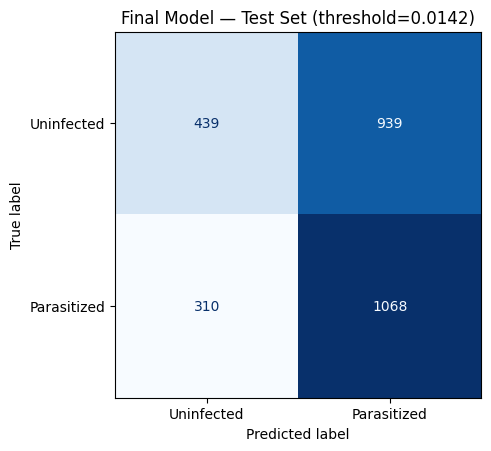

False negatives (missed infections): 310 / 1378 parasitized test images


In [12]:
cm_final = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["Uninfected", "Parasitized"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Final Model — Test Set (threshold={decision_threshold:.4f})")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

false_negatives = cm_final[1, 0]
print(f"False negatives (missed infections): {false_negatives} / {cm_final[1].sum()} parasitized test images")


## 7. Baseline vs. Final Model — Comparison Table

Side-by-side summary for the project report. Note the two rows were scored at **different
thresholds** (baseline at 0.5, final model at its tuned threshold) — that's intentional, since each
reflects how that model would actually be used, not an apples-to-apples threshold comparison.

In [13]:
comparison_df = pd.DataFrame([
    {
        "model": "Baseline (LogReg, HOG+colour-hist)",
        "threshold": 0.5,
        "accuracy": baseline_report["accuracy"],
        "precision_parasitized": baseline_report["Parasitized"]["precision"],
        "recall_parasitized": baseline_report["Parasitized"]["recall"],
        "f1_parasitized": baseline_report["Parasitized"]["f1-score"],
        "auc_roc": baseline_test_auc,
    },
    {
        "model": "Final (EfficientNetB0, fine-tuned)",
        "threshold": decision_threshold,
        "accuracy": final_report["accuracy"],
        "precision_parasitized": final_report["Parasitized"]["precision"],
        "recall_parasitized": final_report["Parasitized"]["recall"],
        "f1_parasitized": final_report["Parasitized"]["f1-score"],
        "auc_roc": final_test_auc,
    },
])

comparison_df.to_csv(os.path.join(REPORTS_DIR, "baseline_vs_final_comparison.csv"), index=False)
comparison_df


,model,threshold,accuracy,precision_parasitized,recall_parasitized,f1_parasitized,auc_roc
0,"Baseline (LogReg, HOG+colour-hist)",0.500000,0.833091,0.846677,0.813498,0.829756,0.913623
1,"Final (EfficientNetB0, fine-tuned)",0.014223,0.546807,0.532138,0.775036,0.631019,0.590576


## 8. Grad-CAM on Test Images — Including False Negatives

Same Grad-CAM implementation as `03_modelling.ipynb` (last conv layer `top_conv`), re-used here on
the test split. Beyond the usual per-class qualitative check, this section specifically visualizes
**false negatives** — parasitized cells the model missed — since understanding *why* those get
missed is more actionable for the report than looking only at correct predictions.

Showing Grad-CAM for 4 false-negative example(s) (of 310 total)


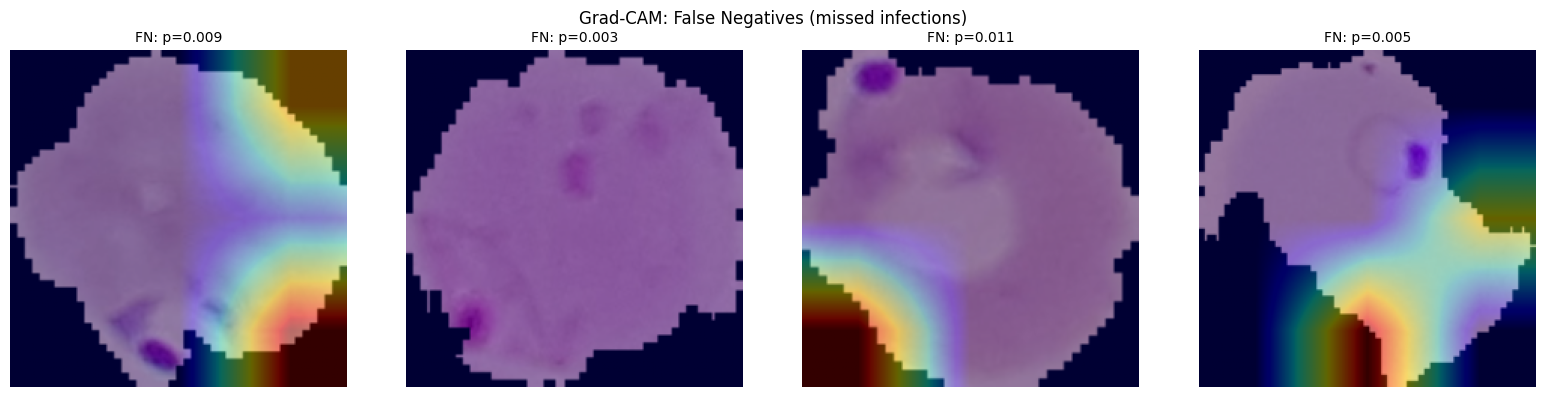

In [14]:
LAST_CONV_LAYER = "out_relu"

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(image, heatmap, alpha=0.4):
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE).numpy().squeeze()
    heatmap_colored = cm.jet(heatmap_resized)[..., :3]

    display_img = (image - image.min()) / (image.max() - image.min() + 1e-8)
    overlaid = display_img * (1 - alpha) + heatmap_colored * alpha
    return overlaid


# Locate false-negative examples: true label = Parasitized (1), predicted = Uninfected (0)
fn_mask = (test_labels == 1) & (test_preds == 0)
fn_positions = np.where(fn_mask)[0][:4]
print(f"Showing Grad-CAM for {len(fn_positions)} false-negative example(s) (of {fn_mask.sum()} total)")

if len(fn_positions) > 0:
    # Rebuild an unbatched, unshuffled view aligned with test_df row order for indexing
    all_images = []
    for images, _ in test_ds:
        all_images.append(images.numpy())
    all_images = np.concatenate(all_images, axis=0)

    n = len(fn_positions)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    axes = np.atleast_1d(axes)
    for col, idx in enumerate(fn_positions):
        img_array = tf.expand_dims(all_images[idx], axis=0)
        # Resize the image to the model's expected input size
        img_array = tf.image.resize(img_array, target_img_size)
        heatmap = make_gradcam_heatmap(img_array, final_model, LAST_CONV_LAYER)
        overlaid = overlay_gradcam(all_images[idx], heatmap)
        axes[col].imshow(overlaid)
        axes[col].set_title(f"FN: p={test_probs[idx]:.3f}", fontsize=10)
        axes[col].axis("off")
    plt.suptitle("Grad-CAM: False Negatives (missed infections)")
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, "gradcam_false_negatives.png"), dpi=150)
    plt.show()
else:
    print("No false negatives in the test set at this threshold — nothing to visualize.")

### Curated Grad-CAM Gallery for the Browser Demo

The false-negative check above confirms the model is attending to real cell structure on the
costliest error class, not guessing. For the deployment demo (`app.js`), we go a step further and
precompute a small, **stratified** gallery of overlays — true positives, true negatives, false
positives, and false negatives — so the browser can show *why* a prediction was made without
reimplementing Grad-CAM in TF.js. Each overlay is saved as a PNG alongside a `manifest.json`
describing the prediction, true label, and probability, ready to copy into `deployment/`.


In [15]:
# Robust last-conv-layer lookup. `LAST_CONV_LAYER` ("out_relu") is correct for
# this MobileNetV2-based POC checkpoint, but hardcoding a layer name is fragile —
# it's the same class of bug that broke the Phase 2 resume logic when the
# EfficientNetB0 backbone was inlined via `input_tensor=` and stopped having a
# layer named "efficientnet...". This falls back to a shape-based scan (last
# layer with a 4D, spatial output) so the gallery cell below still works if the
# model architecture changes.
def find_last_conv_layer(model, preferred_name=None):
    if preferred_name is not None:
        try:
            model.get_layer(preferred_name)
            return preferred_name
        except ValueError:
            print(f"'{preferred_name}' not found in this model — falling back to a shape-based search.")

    for layer in reversed(model.layers):
        try:
            if len(layer.output_shape) == 4:
                return layer.name
        except AttributeError:
            continue
    raise ValueError("No 4D (spatial) layer found — cannot run Grad-CAM on this model.")


last_conv_name = find_last_conv_layer(final_model, preferred_name=LAST_CONV_LAYER)
print(f"Using '{last_conv_name}' as the Grad-CAM target layer.")


Using 'out_relu' as the Grad-CAM target layer.


Saved 12 Grad-CAM overlays + manifest.json to /content/drive/MyDrive/capstone-project/reports/gradcam_gallery


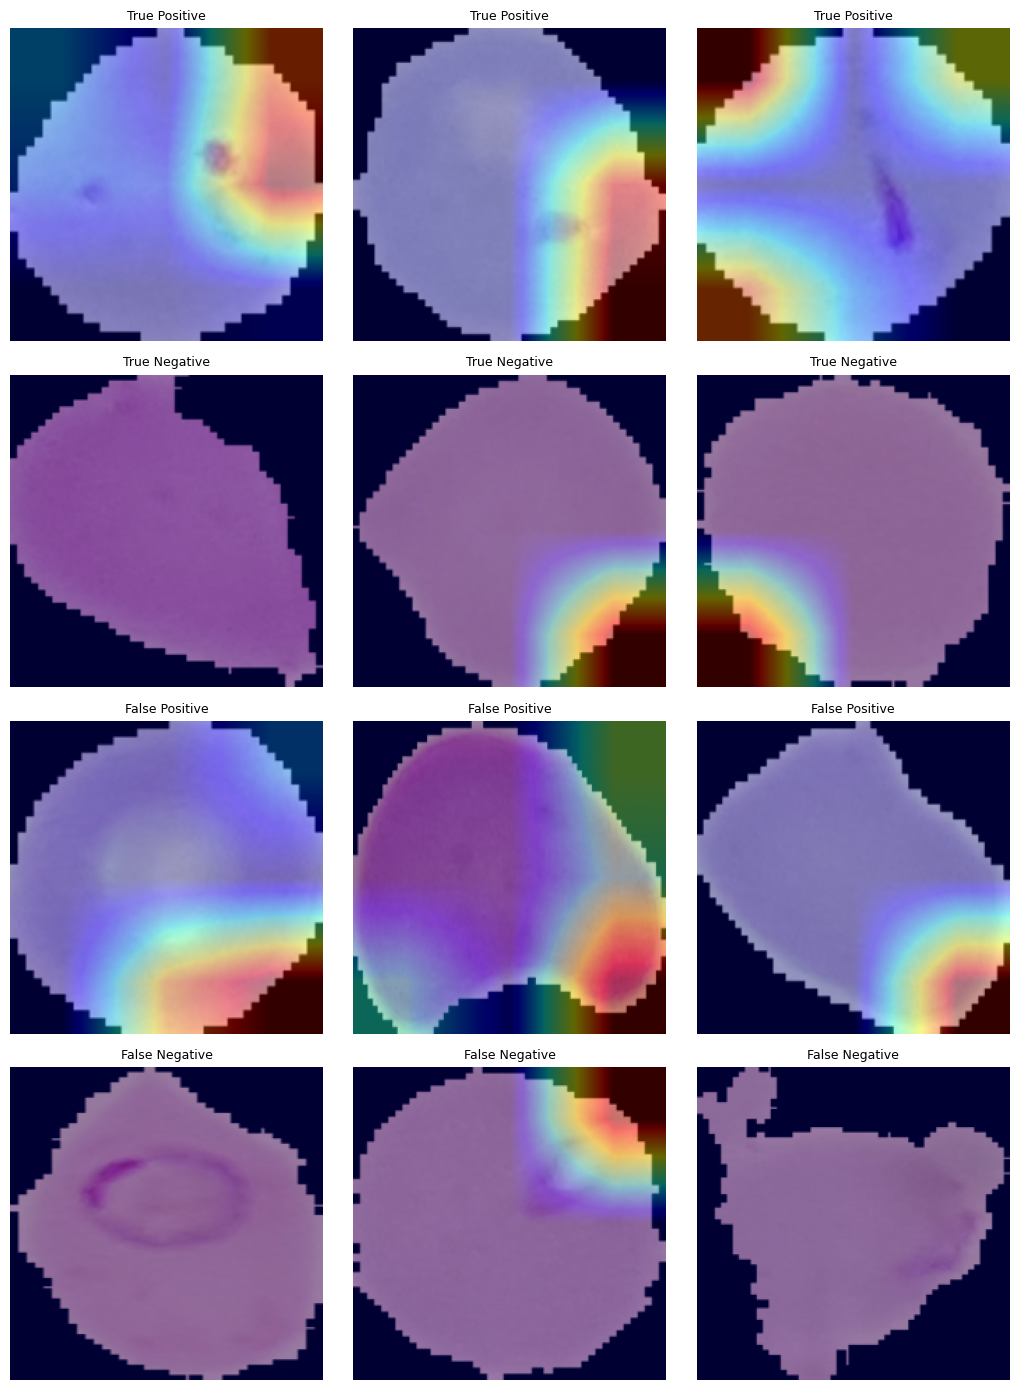

In [16]:
GALLERY_DIR = os.path.join(REPORTS_DIR, "gradcam_gallery")
os.makedirs(GALLERY_DIR, exist_ok=True)

N_PER_CATEGORY = 3

# Rebuilt independently of the false-negative check above so this cell runs on
# its own even if that block found zero false negatives.
all_images = []
for images, _ in test_ds:
    all_images.append(images.numpy())
all_images = np.concatenate(all_images, axis=0)

categories = {
    "true_positive": (test_labels == 1) & (test_preds == 1),
    "true_negative": (test_labels == 0) & (test_preds == 0),
    "false_positive": (test_labels == 0) & (test_preds == 1),
    "false_negative": (test_labels == 1) & (test_preds == 0),
}

rng = np.random.RandomState(RANDOM_SEED)
manifest = []
gallery_grid = {}

for category, mask in categories.items():
    positions = np.where(mask)[0]
    if len(positions) == 0:
        print(f"No examples for '{category}' at this threshold — skipping.")
        continue

    chosen = rng.choice(positions, size=min(N_PER_CATEGORY, len(positions)), replace=False)
    gallery_grid[category] = []

    for i, idx in enumerate(chosen):
        img_array = tf.image.resize(tf.expand_dims(all_images[idx], axis=0), target_img_size)
        heatmap = make_gradcam_heatmap(img_array, final_model, last_conv_name)
        overlaid = overlay_gradcam(all_images[idx], heatmap)
        gallery_grid[category].append(overlaid)

        filename = f"{category}_{i}.png"
        plt.imsave(os.path.join(GALLERY_DIR, filename), np.clip(overlaid, 0, 1))

        manifest.append({
            "filename": filename,
            "category": category,
            "true_label": "Parasitized" if test_labels[idx] == 1 else "Uninfected",
            "predicted_label": "Parasitized" if test_preds[idx] == 1 else "Uninfected",
            "probability": round(float(test_probs[idx]), 4),
            "decision_threshold": round(float(decision_threshold), 4),
        })

with open(os.path.join(GALLERY_DIR, "manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Saved {len(manifest)} Grad-CAM overlays + manifest.json to {GALLERY_DIR}")

# Quick visual sanity check of the gallery before it ships to deployment/
n_rows = len(gallery_grid)
fig, axes = plt.subplots(n_rows, N_PER_CATEGORY, figsize=(3.5 * N_PER_CATEGORY, 3.5 * n_rows))
axes = np.atleast_2d(axes)
for row, (category, imgs) in enumerate(gallery_grid.items()):
    for col in range(N_PER_CATEGORY):
        ax = axes[row][col]
        if col < len(imgs):
            ax.imshow(np.clip(imgs[col], 0, 1))
            ax.set_title(category.replace("_", " ").title(), fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "gradcam_gallery_preview.png"), dpi=150)
plt.show()


## 9. Export to TensorFlow.js

Converts the final Keras model for browser deployment, as planned in `03_modelling.ipynb`'s next
steps. This only applies to the production EfficientNetB0 model — the POC checkpoint is not meant
to be deployed.

In [7]:
from tensorflow import keras

model = keras.models.load_model("/content/drive/MyDrive/capstone-project/models/efficientnetb0_phase1.keras")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,053,416 (15.46 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 2,564 (10.02 KB)

In [21]:
!pip install -q tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 937.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigquery-magics 0.14.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.7.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.42.2 requires packaging>=24.2.0, but you have packaging 

In [4]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/capstone-project/models/efficientnetb0_final.keras"
)

print("Model loaded successfully")

Model loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 44 variables whereas the saved optimizer has 48 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [5]:
import tensorflowjs as tfjs

TFJS_EXPORT_DIR = os.path.join(MODELS_DIR, "tfjs_model")
tfjs.converters.save_keras_model(final_model, TFJS_EXPORT_DIR)
print(f"TensorFlow.js model exported to {TFJS_EXPORT_DIR}")

# Bundle the decision threshold alongside the exported model — the browser app needs it
# to turn the raw sigmoid output into a Parasitized/Uninfected call.
with open(os.path.join(TFJS_EXPORT_DIR, "decision_threshold.json"), "w") as f:
    json.dump(threshold_info, f, indent=2)


VersionError: Detected incompatible Protobuf Gencode/Runtime versions when loading yggdrasil_decision_forests/dataset/data_spec.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.

## 10. Summary

**Artefacts written to `reports/`:**
- `final_test_metrics.json` — final model's test-set classification report + AUC-ROC, at the
  training-tuned decision threshold
- `confusion_matrix.png` — final model's test-set confusion matrix
- `baseline_vs_final_comparison.csv` — side-by-side comparison table for the project report
- `gradcam_false_negatives.png` — qualitative look at the costliest error class

**Artefacts written to `models/`:**
- `tfjs_model/` — the final model converted for browser deployment, with `decision_threshold.json`
  bundled alongside it

**Headline numbers for the report:** final model test AUC-ROC, recall/precision on Parasitized at
the tuned threshold, and the false-negative count from Section 6 — pull these directly from
`final_test_metrics.json` rather than re-typing them, so the report always matches the notebook's
actual output.
